In [62]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.stats as stats # for the target variables analysis

# Load datasets
train = pd.read_csv("ML_WP_data/train.csv")
test = pd.read_csv("ML_WP_data/test.csv")

In [63]:
# Checking the table
train.head()

,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,fkl010h0_STG,fkl010h0_ZER,...,ure200h0_SIO,ure200h0_STG,ure200h0_ZER,tre200h0,tre200h0_lag24h,target_tre200h0_plus12h,target_tre200h0_plus24h,target_tre200h0_plus48h,hour,season
0,1.3,2.1,0.8,8.3,1.0,0.6,0.6,0.5,3.4,0.9,...,84.4,76.0,74.0,12.2,8.5,17.5,10.3,10.0,5.0,Spring
1,3.8,0.8,3.8,14.0,6.9,0.5,2.9,0.6,2.0,1.8,...,87.6,96.3,67.4,4.3,8.9,12.1,1.5,6.3,3.0,Spring
2,1.1,2.0,0.1,10.5,2.1,1.3,1.1,1.7,0.9,1.1,...,81.9,96.5,65.8,-12.3,-7.6,-7.1,-3.5,-2.1,0.0,Winter
3,0.8,3.1,1.8,9.8,1.0,1.9,0.8,0.8,0.5,0.8,...,46.4,83.9,33.7,5.6,8.2,3.2,7.4,6.5,13.0,Autumn
4,4.4,1.6,4.3,2.9,2.2,2.8,6.3,5.4,1.0,2.8,...,39.4,65.7,44.7,20.7,19.2,15.7,21.9,23.9,11.0,Summer


In [64]:
# Checking the table: weather data from Bern
test.head()

,Id,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,fkl010h0_STG,...,ure200h0_GVE,ure200h0_INT,ure200h0_LUG,ure200h0_SIO,ure200h0_STG,ure200h0_ZER,tre200h0,tre200h0_lag24h,hour,season
0,1,8.1,1.7,4.5,13.5,6.8,2.2,0.6,0.6,4.5,...,87.1,96.2,62.5,92.6,85.7,72.9,5.5,5.9,13,Winter
1,2,0.9,1.8,1.3,3.1,0.9,1.6,0.8,0.6,0.8,...,79.3,76.4,59.4,69.4,77.4,33.7,1.9,5.5,18,Winter
2,3,2.9,2.1,0.8,5.8,0.7,0.5,1.1,0.9,4.3,...,72.7,94.3,80.1,84.2,84.5,74.5,17.7,17.5,0,Spring
3,4,5.4,2.6,3.2,5.7,5.2,2.3,0.5,8.2,1.7,...,46.1,54.7,48.4,35.6,60.2,34.8,7.5,4.4,16,Spring
4,5,0.9,0.6,1.1,1.7,0.5,0.7,0.5,0.5,0.6,...,86.5,85.9,81.7,74.3,64.2,65.6,11.7,14.6,1,Spring


In [65]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7579 entries, 0 to 7578
Data columns (total 92 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   fkl010h0_ANT             7578 non-null   float64
 1   fkl010h0_BAS             7576 non-null   float64
 2   fkl010h0_DAV             7576 non-null   float64
 3   fkl010h0_DOL             7578 non-null   float64
 4   fkl010h0_GVE             7578 non-null   float64
 5   fkl010h0_INT             7576 non-null   float64
 6   fkl010h0_LUG             7579 non-null   float64
 7   fkl010h0_SIO             7576 non-null   float64
 8   fkl010h0_STG             7575 non-null   float64
 9   fkl010h0_ZER             7578 non-null   float64
 10  fkl010h3_ANT             7576 non-null   float64
 11  fkl010h3_BAS             7579 non-null   float64
 12  fkl010h3_DAV             7576 non-null   float64
 13  fkl010h3_DOL             7579 non-null   float64
 14  fkl010h3_GVE            

In [66]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3247 entries, 0 to 3246
Data columns (total 90 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               3247 non-null   int64  
 1   fkl010h0_ANT     3247 non-null   float64
 2   fkl010h0_BAS     3247 non-null   float64
 3   fkl010h0_DAV     3247 non-null   float64
 4   fkl010h0_DOL     3247 non-null   float64
 5   fkl010h0_GVE     3247 non-null   float64
 6   fkl010h0_INT     3247 non-null   float64
 7   fkl010h0_LUG     3247 non-null   float64
 8   fkl010h0_SIO     3247 non-null   float64
 9   fkl010h0_STG     3247 non-null   float64
 10  fkl010h0_ZER     3247 non-null   float64
 11  fkl010h3_ANT     3247 non-null   float64
 12  fkl010h3_BAS     3247 non-null   float64
 13  fkl010h3_DAV     3247 non-null   float64
 14  fkl010h3_DOL     3247 non-null   float64
 15  fkl010h3_GVE     3247 non-null   float64
 16  fkl010h3_INT     3247 non-null   float64
 17  fkl010h3_LUG  

In [67]:
# Exploratory Data Analysis

## Missing Value Summary and Dispersion Analysis

In [68]:
# Getting the variables with missing values, the amount and the percentage
missing_summary = (
    pd.DataFrame({
        'Data_Type': train.dtypes,
        'Missing_Values': train.isnull().sum(),
        'Percent_Missing': (train.isnull().sum() / len(train) * 100).round(2)
    })
    .query("Missing_Values > 0")
    .sort_values(by='Missing_Values', ascending=False)
)

# Getting a statistical summary of the dataset (like what .describe() returns)
summary_stats = train.describe(include='all').transpose()

# Merging missing summary with descriptive stats for better insight
merged_summary = missing_summary.merge(
    summary_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']],
    left_index=True,
    right_index=True,
    how='left'
)

print(merged_summary.to_string())

# Print the total number of variables with missing values
print(f"\nTotal variables with missing values: {len(missing_summary)}")

# Identify all target columns (the temperature variables we need to predict)
target_columns = train.filter(like='target').columns.tolist()

                        Data_Type  Missing_Values  Percent_Missing         mean         std    min     25%     50%     75%     max
tre200h0_BAS              float64               4             0.05    11.715525    7.885066  -12.7     5.6    11.4    17.4    35.9
ure200h0_ANT              float64               4             0.05    75.620066   16.451426   15.5    64.1    79.6    89.4   100.0
ure200h0_STG              float64               4             0.05    74.420568   17.349778   16.4    62.5    77.1    88.6   100.0
tre200h0_lag24h           float64               4             0.05    10.012568    8.081936  -11.3     3.5     9.7   15.85    34.3
rre150h0_ANT              float64               4             0.05     0.118231    0.562748    0.0     0.0     0.0     0.0    12.8
fkl010h0_STG              float64               4             0.05     2.062733    1.509565    0.0     1.0     1.7     2.7    12.1
ure200h0_DAV              float64               4             0.05    72.885373   1

## Key observations of the Missing Value Summary and Dispersion Analysis

* **Precipitation (`rre150h0_*`)** – *rre150h0: Precipitation; hourly total*  
  * Most hourly values are zero (25%, 50%, 75% = 0).  
  * Maximum values up to 41.7 mm/hour (e.g., Lugano) are realistic for Swiss storms.  
  * Very small means and large standard deviations indicate strong right skew.  
  * These “outliers” are genuine rainfall events, not errors.

* **Global radiation (`gre000h0_*`)** – *gre000h0: Global radiation; hourly mean*  
  * Many zeros at night; daytime values reach up to around 1000 W/m².  
  * High standard deviation (~250 W/m²) reflects day–night cycles.  
  * Strongly skewed, possibly bimodal distribution (night vs. day).

* **Atmospheric pressure (`prestah0_*`)** – *prestah0: Atmospheric pressure at barometric altitude (QFE); hourly mean*  
  * Narrow ranges (~7 hPa std) consistent with expected altitudes.  
  * No missing or implausible values detected.  
  * Excellent sensor consistency across stations.

* **Temperature (`tre200h0_*`)** – *tre200h0: Temperature at 2 m above ground; hourly mean*  
  * Mean temperature varies by station (≈ 4 °C in Davos/Andermatt, ≈ 13 °C in Lugano).  
  * Ranges from −23 °C to +38 °C, plausible for Swiss seasonal extremes.  
  * Differences in means due to elevation, not data quality issues.

* **Humidity (`ure200h0_*`)** – *ure200h0: Relative air humidity 2 m above ground; hourly mean*  
  * Mostly within 0–100 %; rare minima (≈ 2–3 %) possible in very dry air.  
  * Some near-100 % readings are expected under saturated conditions.  
  * Physically bounded variable; clipping can be applied if needed.

* **Wind (`fkl010h*_*`)** – *fkl010h1: Gust peak (one second); hourly maximum in m/s*  
  * Substantial variability; some locations (La Dôle, Andermatt) show strong gusts.  
  * Distributions are right-skewed with high maxima but physically plausible.  
  * Reflects natural geographic differences rather than anomalies.

🎯 **Target columns in the dataset:**
- target_tre200h0_plus12h  
- target_tre200h0_plus24h  
- target_tre200h0_plus48h  

### Preprocessing recommendations

| Variable group                                       | Issues identified                    | Suggested action                                                |
| ---------------------------------------------------- | ------------------------------------ | --------------------------------------------------------------- |
| **Pressure**                                         | None                                 | Keep as is                                                      |
| **Temperature**                                      | Different baselines between stations | Apply Z-score normalisation per station                         |
| **Humidity**                                         | Physically bounded (0–100 %)         | Clip values to [0, 100]                                         |
| **Precipitation, Radiation, Wind**                   | Heavy right skew, many zeros         | Optionally apply log(1 + x) transformation before linear models |
| **Targets (`target_tre200h0_+12h`, `+24h`, `+48h`)** | No missing values                    | Keep as dependent variables                                     |

| Code  | Station    | Region    | Terrain type        |
|-------|-------------|-----------|---------------------|
| BAS   | Basel       | North     | Lowland             |
| GVE   | Genève      | West      | Lowland             |
| INT   | Interlaken  | Central   | Valley              |
| SIO   | Sion        | South     | Alpine valley       |
| STG   | St-Gallen   | Northeast | Foothills           |
| DAV   | Davos       | East      | High Alpine         |
| ZER   | Zermatt     | South     | High Alpine         |
| ANT   | Andermatt   | Central   | Mountain pass       |
| DOL   | La Dôle     | West      | Jura mountains      |
| LUG   | Lugano      | South     | Pre-Alpine / Ticino |

In [69]:
# Select only numeric columns
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# If you want to exclude targets, do it here:
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]
numeric_cols = [c for c in numeric_cols if c not in targets]

# Function to detect outliers using the IQR rule
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

# Apply to all numeric columns
outlier_summary = {}
for col in numeric_cols:
    n_outliers = len(detect_outliers(train, col))
    outlier_summary[col] = n_outliers

# Convert to DataFrame for easier analysis
outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=["Variable", "Outlier_Count"])
outlier_df["Outlier_%"] = (outlier_df["Outlier_Count"] / len(train)) * 100
outlier_df.sort_values(by="Outlier_%", ascending=False, inplace=True)

display(outlier_df.head(20))  # show top 15 variables with most outliers


,Variable,Outlier_Count,Outlier_%
60,sre000h0_INT,1783,23.525531
64,sre000h0_ZER,1782,23.512337
55,sre000h0_ANT,1752,23.116506
63,sre000h0_STG,1581,20.860272
56,sre000h0_BAS,1578,20.820689
57,sre000h0_DAV,1549,20.438053
59,sre000h0_GVE,1444,19.052645
58,sre000h0_DOL,1371,18.089458
48,rre150h0_DOL,1353,17.851959
45,rre150h0_ANT,1117,14.738092


Como vemos en la tabla, hay variables con gran porcentaje de observaciones consideradas extremas. Sin embargo, al comprobar la localización geográfica de esa observación, podemos concluir que más que valores extremos propios de un error de medición, estos valores se deben a la gran variabilidad geográfica y por ende meteorológica de Suiza.
En otras palabras, el IQR no toma en consideración el lugar en el que las mediciones fueron tomadas. Para referencia, hemos incluido una tabla con las localizaciones de las estaciones meteorológicas de esta base de datos.
En conclusión, no recomendamos eliminar los valores extremos, ya que, por ejemplo, una lluvia intensa en Davos, podría predecir una caída de temperaturas en Berna en las próximas 24h.

Winsorisation is not recommended either since the outliers are likely a real phenomenon and not measurement errors and winsorising would distort the weather distribution.

pair.plot de seaborn

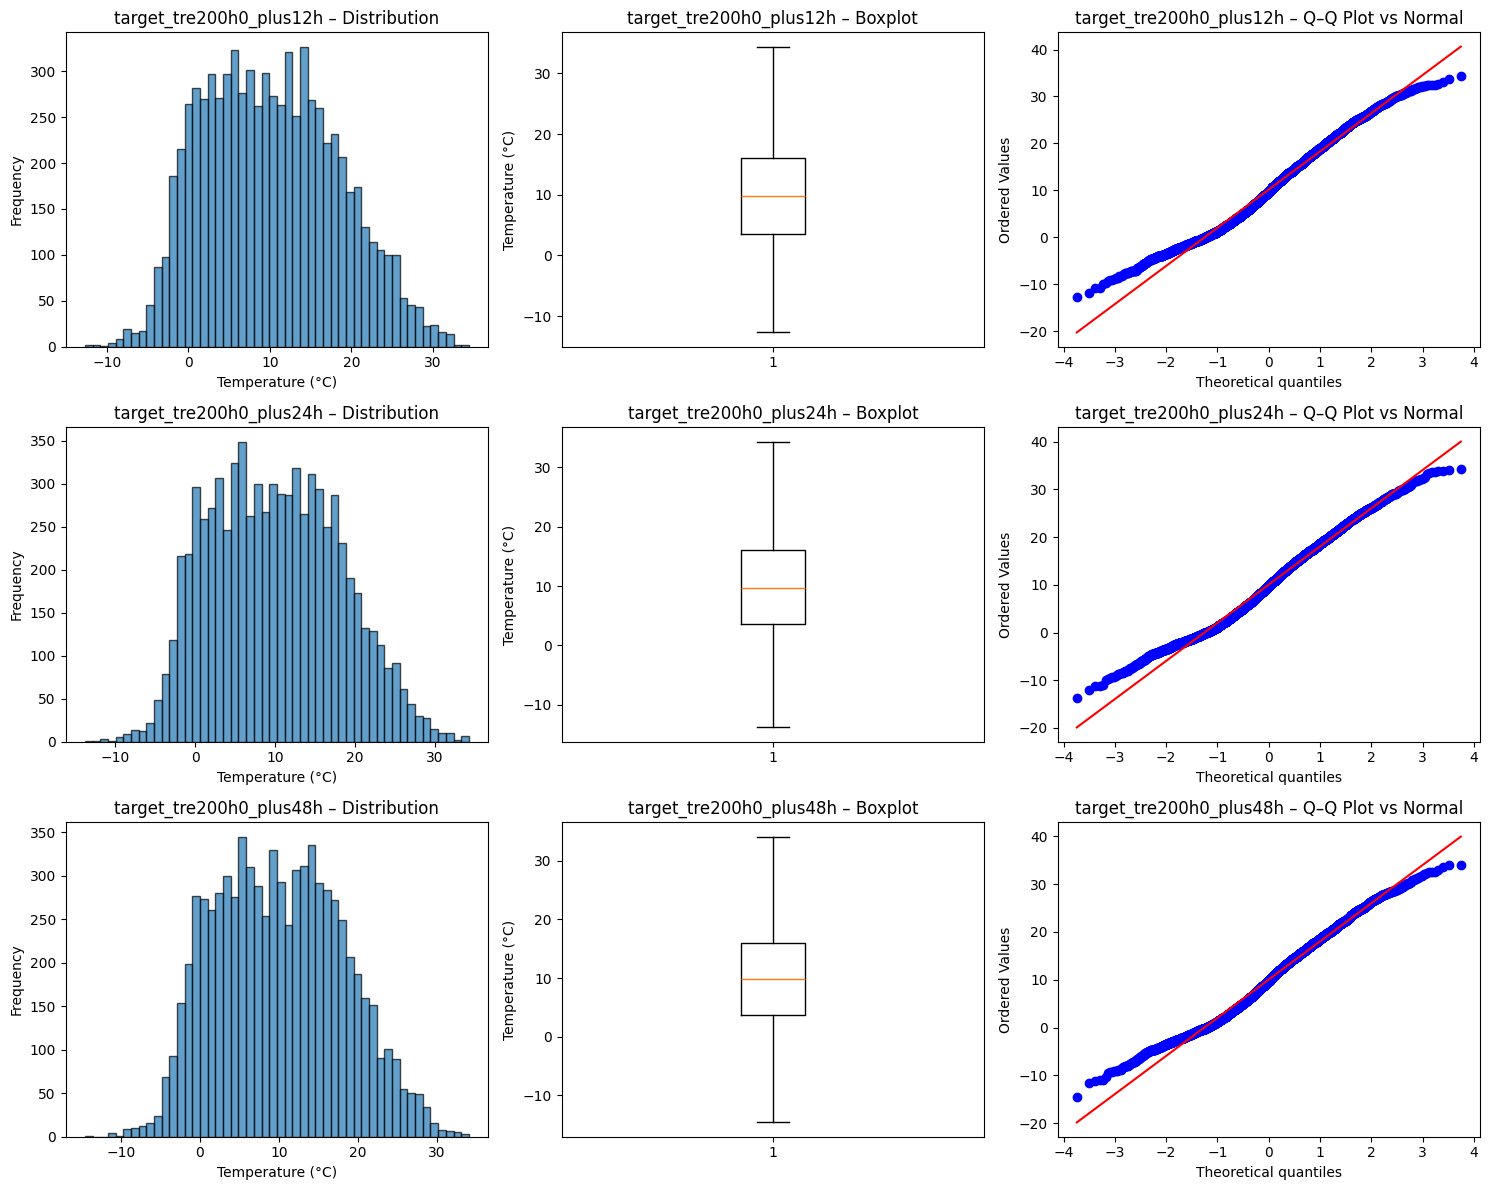

In [70]:
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]

fig, axes = plt.subplots(len(targets), 3, figsize=(15, 12))

for i, target_col in enumerate(targets):
    # Histogram
    axes[i, 0].hist(train[target_col], bins=50, edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f"{target_col} – Distribution")
    axes[i, 0].set_xlabel("Temperature (°C)")
    axes[i, 0].set_ylabel("Frequency")

    # Boxplot
    axes[i, 1].boxplot(train[target_col].dropna(), vert=True)
    axes[i, 1].set_title(f"{target_col} – Boxplot")
    axes[i, 1].set_ylabel("Temperature (°C)")

    # Q–Q plot
    stats.probplot(train[target_col].dropna(), dist="norm", plot=axes[i, 2])
    axes[i, 2].set_title(f"{target_col} – Q–Q Plot vs Normal")

plt.tight_layout()
plt.show()


Como vemos en los histogramas de arriba a la izquierda, las tres variables objetivo están normalmente distribuidas y son simétricas en torno a, más o menos, 10 grados centígrados. El rango de dichas vairables, (+/- -15º hasta +25ºC) es también metorológicamente plausible y muestra la variablidad estacional. Los boxplots confirman esto, pocas observaciones por debajo de los 10 grados o por encima de los 35º, sin outliers. Además, los IQR son consistentes a través de las tres variables objetivo. Por último, los QQplots confirman una distribución muy cercana a la normal, con una ligera desviación de la distribución normal en valores extremos, posiblemente a causa de eventos meteorológicos extremos (heladas extremas u olas de calor). Conforme el horizonte de la predicción se hace más grande, vemos como ligeramente, la distribución es menos normal.

Considerando estas observaciones sobre la distribución de la variable objetivo, podemos considerar que se distribuye suficientemente normal por lo que no sería necesario una corrección de normalidad como la Box-Cox.

In [71]:
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]

for t in targets:
    clean_series = train[t].dropna()  # remove missing values
    clean_series = clean_series[np.isfinite(clean_series)]  # remove inf/-inf if any
    skew = stats.skew(clean_series)
    kurt = stats.kurtosis(clean_series)
    print(f"{t}: Skewness = {skew:.3f}, Kurtosis = {kurt:.3f}")

target_tre200h0_plus12h: Skewness = 0.242, Kurtosis = -0.622
target_tre200h0_plus24h: Skewness = 0.199, Kurtosis = -0.624
target_tre200h0_plus48h: Skewness = 0.179, Kurtosis = -0.643


Los resultados que vimos en el histograma, boxplot y QQplot de arriba son confirmados por el análisis de skwenness. Al estar las tres variables objetivos con una skewness baja (sobre los 0.2 puntos), esto nos indica que hay ligreamente más temperaturas sobre cero que inferiores, cosa dentro de lo normal en mediciones de temperatura.
Respecto a la kurtosis, vemos como las tres variables tienen una ligera kurtosis negativa, indicando que las distribuciones son algo más planas y con colas más ligeras que una distribución normal.

## Missing Values

Top hours with most missing values:

hour
13.0    15
20.0    10
6.0      9
16.0     9
10.0     9
12.0     8
23.0     7
2.0      7
11.0     6
22.0     6
Name: missing_count, dtype: int64


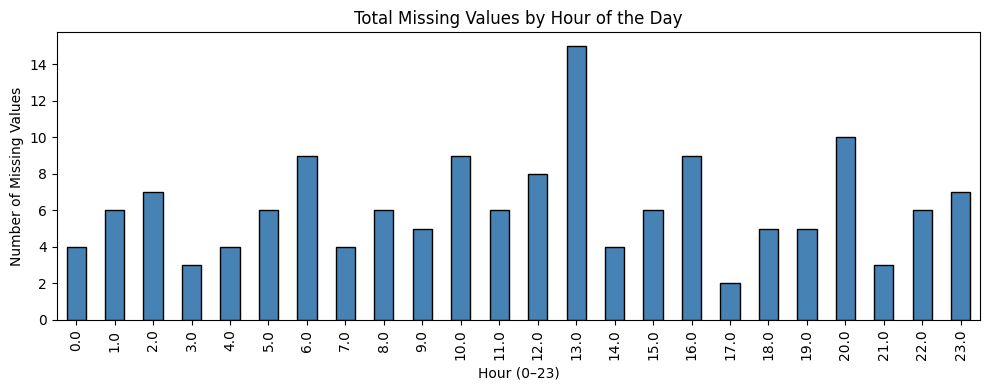

Chi-square statistic: 29.31
p-value: 0.1703
→ No significant hourly difference (fail to reject H₀).


In [72]:
# Count missing values per row
train['missing_count'] = train.isnull().sum(axis=1)

# Group by hour and compute total missing values
missing_by_hour = (
    train.groupby('hour')['missing_count']
    .sum()
    .sort_values(ascending=False)
)

# Display top 10 hours with most missing values
print("Top hours with most missing values:\n")
print(missing_by_hour.head(10))


# Plot distribution of missing values by hour
plt.figure(figsize=(10, 4))
missing_by_hour.sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Total Missing Values by Hour of the Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Missing Values")
plt.tight_layout()
plt.show()

# test for hourly missingness
from scipy.stats import chi2_contingency, f_oneway

# Count missing values per hour
missing_by_hour = train.groupby('hour')['missing_count'].sum()

# Chi-square goodness-of-fit test
# Null: all hours have equal missing counts
expected = [missing_by_hour.sum() / len(missing_by_hour)] * len(missing_by_hour)
chi2_stat = ((missing_by_hour - expected)**2 / expected).sum()

from scipy.stats import chi2
p_value = 1 - chi2.cdf(chi2_stat, df=len(missing_by_hour)-1)

print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("→ Missingness differs significantly by hour (reject H₀).")
else:
    print("→ No significant hourly difference (fail to reject H₀).")


Como vemos en el gráfico de barras de arriba, los valores ausentes parecen más o menos uniformemente distribuidos a través de las horas del día, con tan solo pequeñas fluctuaciones y un ligero pico a las 13h. En general, podríamos decir que no hay patrones horarios sistemáticos en la falta de observaciones. Esto es confirmado mediante el test de chi-cuadrado, con una p-value superior a 0.05, en otras palabras, no podemos rechazar la hipótesis nula de independencia entre hora y ausencia de observaciones. En conclusión, estos datos podrían ser descritos como Missing Completetly at Random (MCAR) respecto a la hora del día.


Missing values by season:
season
Winter    28
Spring    34
Summer    47
Autumn    40
Name: missing_count, dtype: int64


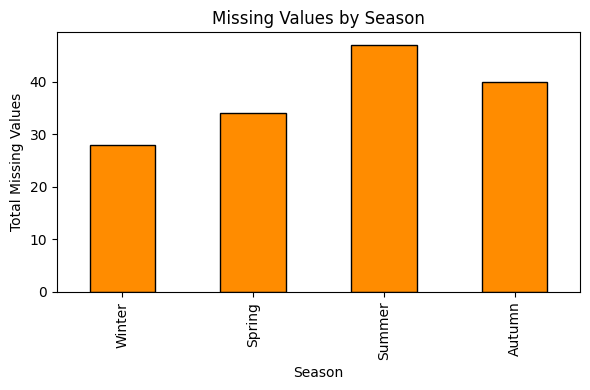

=== Chi-square Test for Seasonal Missingness ===
Chi-square statistic: 5.34
p-value: 0.1488
→ No significant seasonal difference (fail to reject H₀).

=== ANOVA Test for Seasonal Missingness ===
               sum_sq      df         F    PR(>F)
C(season)    0.118765     3.0  2.054394  0.104031
Residual   145.951570  7574.0       NaN       NaN


In [73]:
# 4. (Optional) Do the same for season, if available
if 'season' in train.columns:
    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    missing_by_season = (
        train.groupby('season')['missing_count']
        .sum()
        .reindex(season_order)
    )

    print("\nMissing values by season:")
    print(missing_by_season)

    plt.figure(figsize=(6, 4))
    missing_by_season.plot(kind='bar', color='darkorange', edgecolor='black')
    plt.title("Missing Values by Season")
    plt.xlabel("Season")
    plt.ylabel("Total Missing Values")
    plt.tight_layout()
    plt.show()

from scipy.stats import chi2
import statsmodels.api as sm
from statsmodels.formula.api import ols

# --- Chi-square test: Missing values by season ---
missing_by_season = train.groupby('season')['missing_count'].sum()

# Expected equal distribution of missingness
expected = [missing_by_season.sum() / len(missing_by_season)] * len(missing_by_season)

chi2_stat = ((missing_by_season - expected) ** 2 / expected).sum()
p_value = 1 - chi2.cdf(chi2_stat, df=len(missing_by_season) - 1)

print("=== Chi-square Test for Seasonal Missingness ===")
print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("→ Missingness differs significantly by season (reject H₀).")
else:
    print("→ No significant seasonal difference (fail to reject H₀).")

# --- Optional: ANOVA test for mean missing_count across seasons ---
model = ols('missing_count ~ C(season)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n=== ANOVA Test for Seasonal Missingness ===")
print(anova_table)


Como se observa en el gráfico anterior, los valores ausentes son más frecuentes en verano, con un total de 47, y en otoño, con 40. La ausencia de datos es independiente de la estación en la que se producen, ya que el test chi-cuadrado presenta un p-valor superior a 0.05; por tanto, no se rechaza la hipótesis nula $H_0$. En consecuencia, la ausencia de datos es aleatoria y despreciable, como muestran los números absolutos de valores faltantes. En otras palabras, estos valores ausentes representan ruido aleatorio.

A modo de conclusión, tanto los análisis por hora como por estación indican que las observaciones ausentes están distribuidas de manera aleatoria en el tiempo. Los test chi-cuadrado y ANOVA muestran que no existen diferencias estadísticamente significativas entre horas ni estaciones (p-valor superior a 0.05). Por ello, las observaciones ausentes son consistentes con un patrón de tipo Missing Completely at Random (MCAR). Esto justifica el uso de técnicas de imputación simple, ya que la ausencia de observaciones y su posterior imputación no introducirían sesgos en el entrenamiento de los modelos estadísticos.


## Posible code to drop nas or impute values

In [ ]:
from sklearn.impute import SimpleImputer

# Preserve the original
base = train.copy()

# Identify columns
num_cols = base.select_dtypes(include='number').columns
cat_cols = base.select_dtypes(exclude='number').columns

# 1) Drop rows with any NA
train_drop = base.dropna()

# 2) Mean-imputed (numeric) + mode-imputed (categorical)
mean_imputer = SimpleImputer(strategy='mean')
train_mean_imp = base.copy()
train_mean_imp[num_cols] = mean_imputer.fit_transform(train_mean_imp[num_cols])

if len(cat_cols) > 0:
    cat_modes = train_mean_imp[cat_cols].mode().iloc[0]
    # Assign back without inplace to avoid warnings
    train_mean_imp[cat_cols] = train_mean_imp[cat_cols].fillna(cat_modes)

# 3) Median-imputed (numeric) + mode-imputed (categorical)
median_imputer = SimpleImputer(strategy='median')
train_median_imp = base.copy()
train_median_imp[num_cols] = median_imputer.fit_transform(train_median_imp[num_cols])

if len(cat_cols) > 0:
    cat_modes = train_median_imp[cat_cols].mode().iloc[0]
    train_median_imp[cat_cols] = train_median_imp[cat_cols].fillna(cat_modes)

# Sanity checks
print(f"Rows before drop: {len(base)}, after drop: {len(train_drop)}")
print("Remaining NAs after drop:", train_drop.isnull().sum().sum())
print("Remaining NAs after mean imputation:", train_mean_imp.isnull().sum().sum())
print("Remaining NAs after median imputation:", train_median_imp.isnull().sum().sum())
print("\nShapes:",
      "\n- Dropped:", train_drop.shape,
      "\n- Mean-imputed:", train_mean_imp.shape,
      "\n- Median-imputed:", train_median_imp.shape)


Rows before drop: 7579, after drop: 7429
Remaining NAs after drop: 0
Remaining NAs after mean imputation: 0
Remaining NAs after median imputation: 0

Shapes: 
- Dropped: (7429, 93) 
- Mean-imputed: (7579, 93) 
- Median-imputed: (7579, 93)


## Correlation Analysis

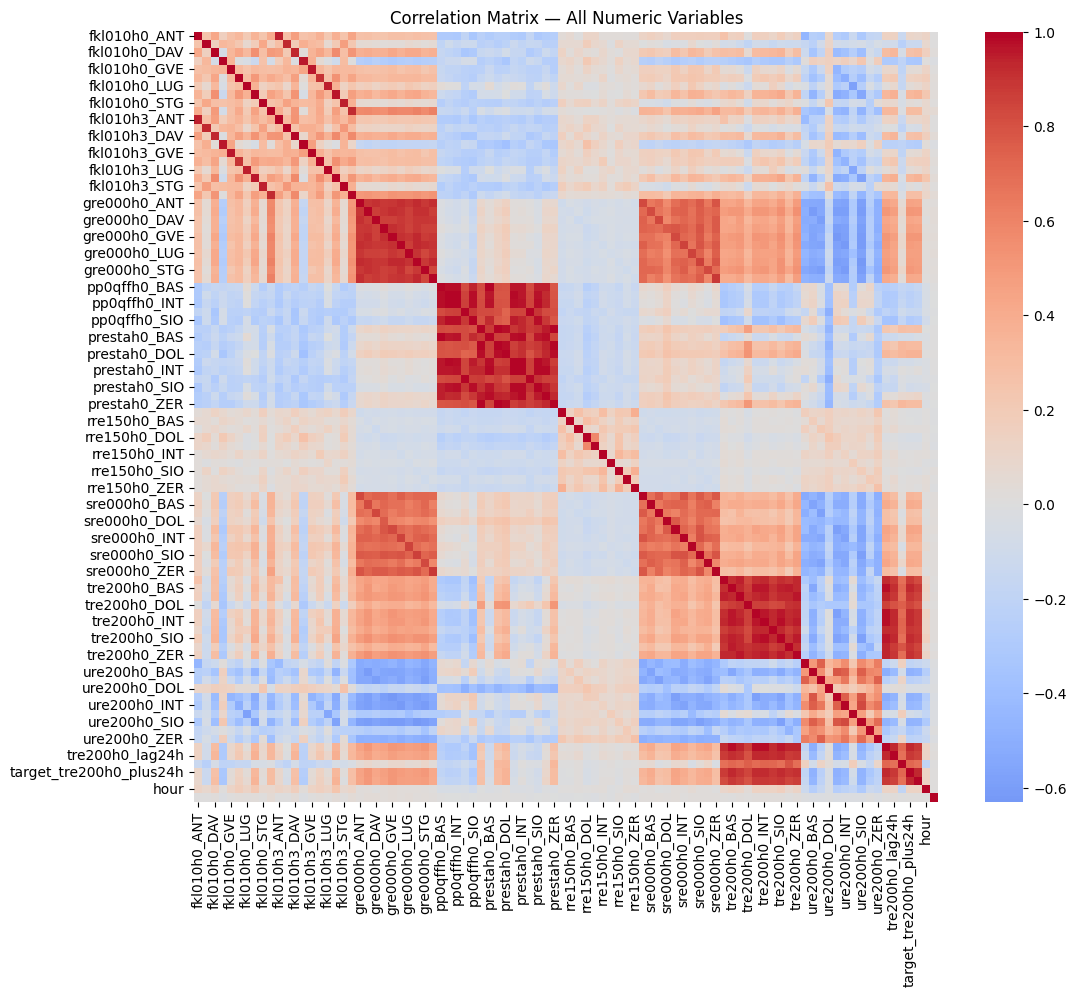

In [75]:
# Compute the correlation matrix for all numeric variables
corr = train.corr(numeric_only=True)

# Display the overall heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — All Numeric Variables")
plt.show()

El el gráfico de correlaciones arriba, vemos como hay una gran correlación intravariable en cada estación meteorológica como en la variable gre000h0 (que mide la radiación) o en prestah0 (que mide la presión atmosférica). Esto no es anómalo, puesto que las estaciones meteorológicas son espacialmente coherentes, en otras palabras, las temperaturas y presiones atmosféricas se mueven de manera armoniosa. Del mismo modo, hay correlaciones cruzadas débiles entre variables. Por ejemplo, la variable tre200h0 (temperatura) está correlacionada positivamente con gre000h0 (radiación) y negativamente con ure200h0 (humedad). De igual modo, rre150h0(precipitaciones) está correlacionada negativamente con gre000h0 (radiación), lo que nos indica consistencia en términos meteorológicos (los valores de las variables están dentro de los rangos esperados para Suiza)

Sin embargo, la alta correlación entre variables implica multicolinealidad, es decir, la presencia de información redundante entre predictores que puede distorsionar el ajuste de ciertos modelos. Esta multicolinearidad no afecta a la capacidad predictiva de nuestros modelos, pero si podría inflar la varianza de los coeficientes y desestabilizar los modelos lineales o de regresión. Para neutralizar este impacto negativo, se podrían aplicar un Principal Analysis Components (PCA) con la cuál reduciríamos la dimensionalidad de los datos. También se podrían eliminar las variables altamente correlacionadas, evitando así redundancias.

# Predictor Transformation

First we would normalise or standardise all the predictors (standardscaler)
Then we might want to do a PCA

In [ ]:
# Z-score normalisation per variable (per station)
for col in train.columns:
    if any(prefix in col for prefix in ['fkl010h', 'gre000h0', 'rre150h0', 'prestah0', 'ure200h0', 'tre200h0']):
        train[col] = (train[col] - train[col].mean()) / train[col].std()

# or better this one right? since it keeps mean and sd?
scaler = StandardScaler()
cols_to_scale = [c for c in train.columns if any(p in c for p in 
                 ['fkl010h', 'gre000h0', 'rre150h0', 'prestah0', 'ure200h0', 'tre200h0'])]

train[cols_to_scale] = scaler.fit_transform(train[cols_to_scale])

#minmaxscaler: probar

Sugerimos mantener la versión que obtenemos con `StandardScaler`ya que nos permite guardar la media y la desviación típica, asegurandonos consistencia entre los dataset de train y test.
Esto es esencial pata el futuro PCA y la utilización de modelos que sean sensibles a la escala de las variables.
